# Diabetes Prediction (ML)

This notebook presents an end-to-end machine learning workflow for predicting diabetes risk from patient health-related features.

## Notebook Goals
- Load and inspect the dataset
- Perform exploratory data analysis (EDA)
- Clean and preprocess the data
- Engineer useful features
- Train and compare multiple machine learning models
- Evaluate performance with suitable metrics

## 1. Import Libraries

In [92]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. The XGBoost section will be skipped.")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [93]:
# Expected project structure:
# Diabetes-Prediction-ML/
# ├── data/
# │   └── diabetes_prediction_dataset.csv
# └── notebooks/
#     └── diabetes_prediction.ipynb

df = pd.read_csv("/content/diabetes_prediction_dataset.csv.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Initial Data Inspection

In [94]:
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")

Shape: (100000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [96]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


In [97]:
missing_values = df.isnull().sum().sort_values(ascending=False)
duplicates_count = df.duplicated().sum()

print("Missing values per column:")
print(missing_values)

print(f"\nNumber of duplicated rows: {duplicates_count}")

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Number of duplicated rows: 3854


In [98]:
print("\nDistribution of 'gender':")
print(df['gender'].value_counts())

print('='*20)

print("\nDistribution of 'smoking_history':")
print(df['smoking_history'].value_counts())

print('='*20)

print("\nDistribution of 'diabetes':")
print(df['diabetes'].value_counts())


Distribution of 'gender':
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Distribution of 'smoking_history':
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Distribution of 'diabetes':
diabetes
0    91500
1     8500
Name: count, dtype: int64


## 4. Data Cleaning

In [99]:
# Remove duplicated rows
df = df.drop_duplicates().copy()

# Handle the 'Other' category in gender by replacing it with the mode
if "gender" in df.columns and "Other" in df["gender"].unique():
    gender_mode = df.loc[df["gender"] != "Other", "gender"].mode()[0]
    df["gender"] = df["gender"].replace("Other", gender_mode)

print(f"New shape after cleaning: {df.shape}")
df.head()

New shape after cleaning: (96146, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [100]:
# Cap BMI outliers using the IQR method (winsorization-like treatment)
outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"Number of outliers in BMI: {len(outliers)}")

if "bmi" in df.columns:
    Q1 = df["bmi"].quantile(0.25)
    Q3 = df["bmi"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df["bmi"] = np.where(
        df["bmi"] < lower_bound,
        lower_bound,
        np.where(df["bmi"] > upper_bound, upper_bound, df["bmi"])
    )

    print(f"BMI capped to range: [{df['bmi'].min():.2f}, {df['bmi'].max():.2f}]")

Number of outliers in BMI: 5354
BMI capped to range: [13.71, 39.55]


In [101]:
print(f"Shape: {df.shape}")

Shape: (96146, 9)


## 5. Exploratory Data Analysis (EDA)

In [102]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Categorical columns: ['gender', 'smoking_history']


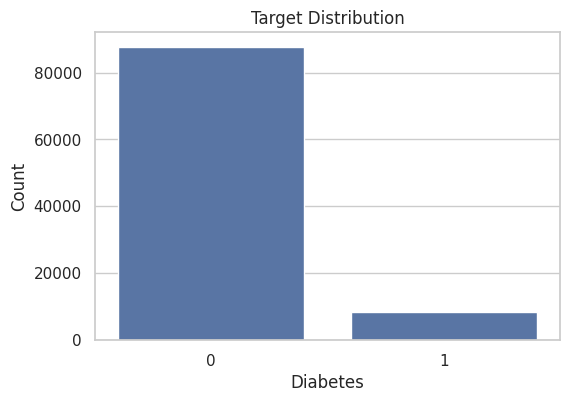

Target percentage:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


In [103]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes")
plt.title("Target Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

print("Target percentage:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

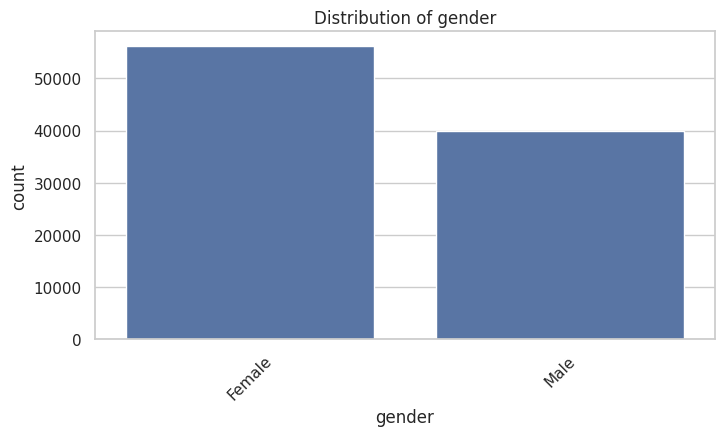

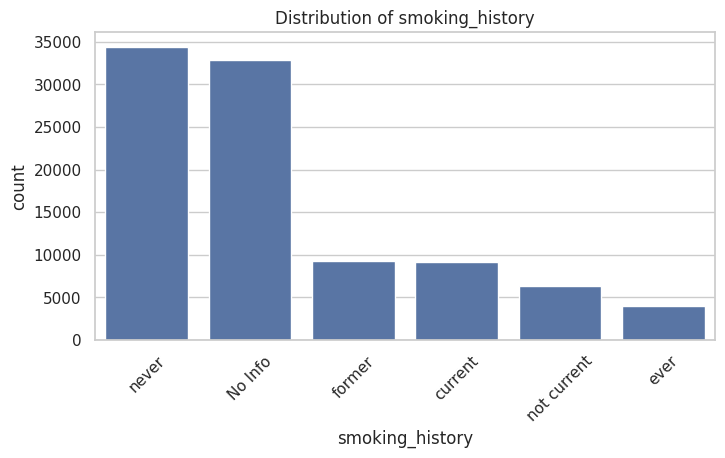

In [104]:
# Distribution of categorical features
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

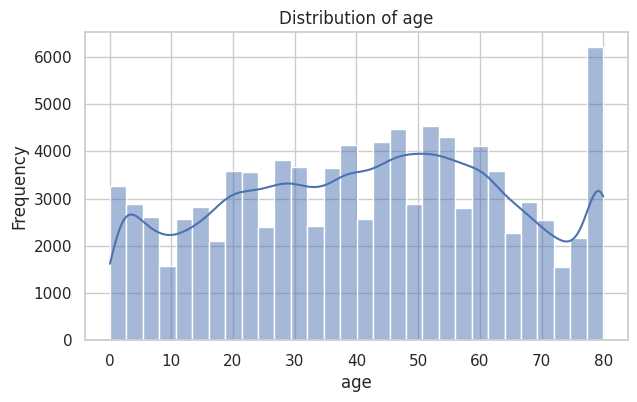

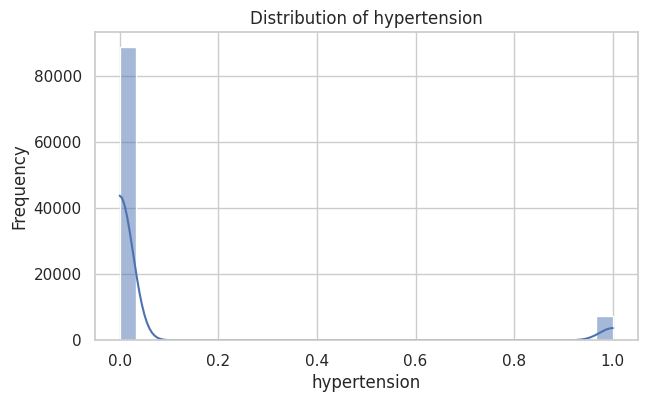

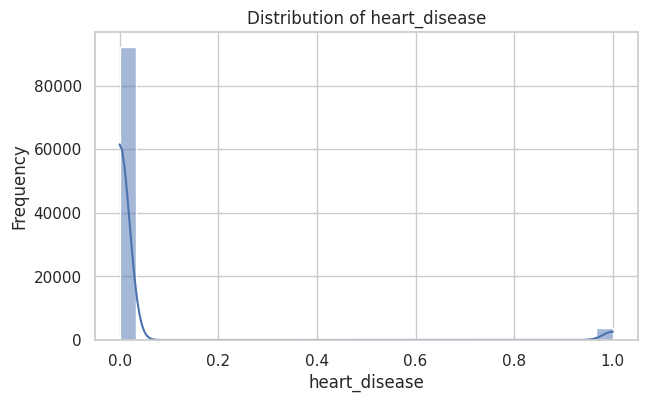

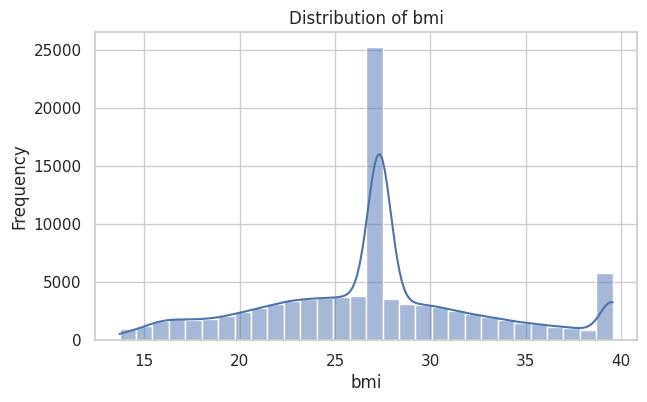

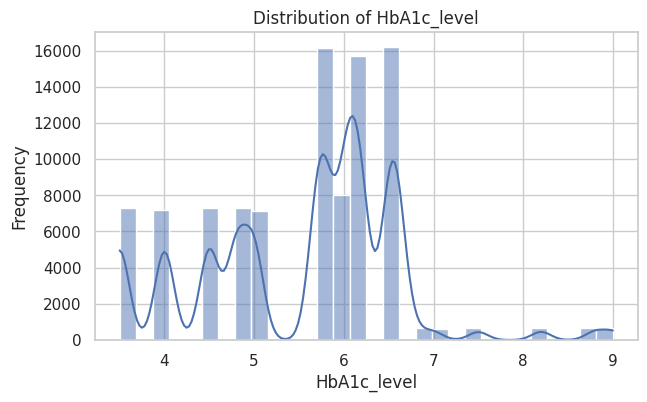

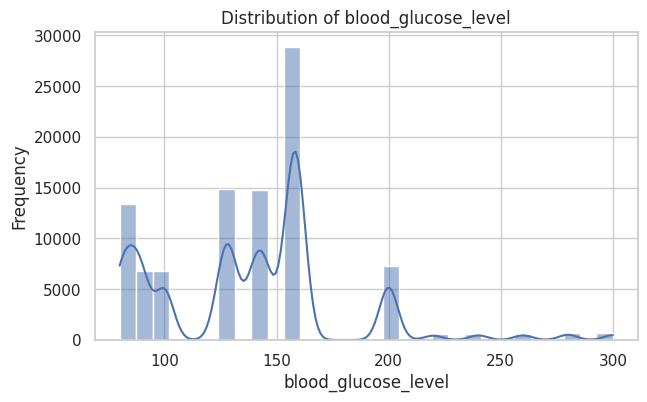

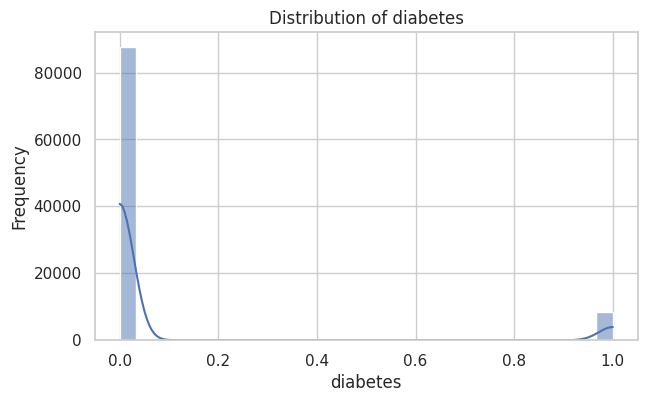

In [105]:
# Distribution of numerical features
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

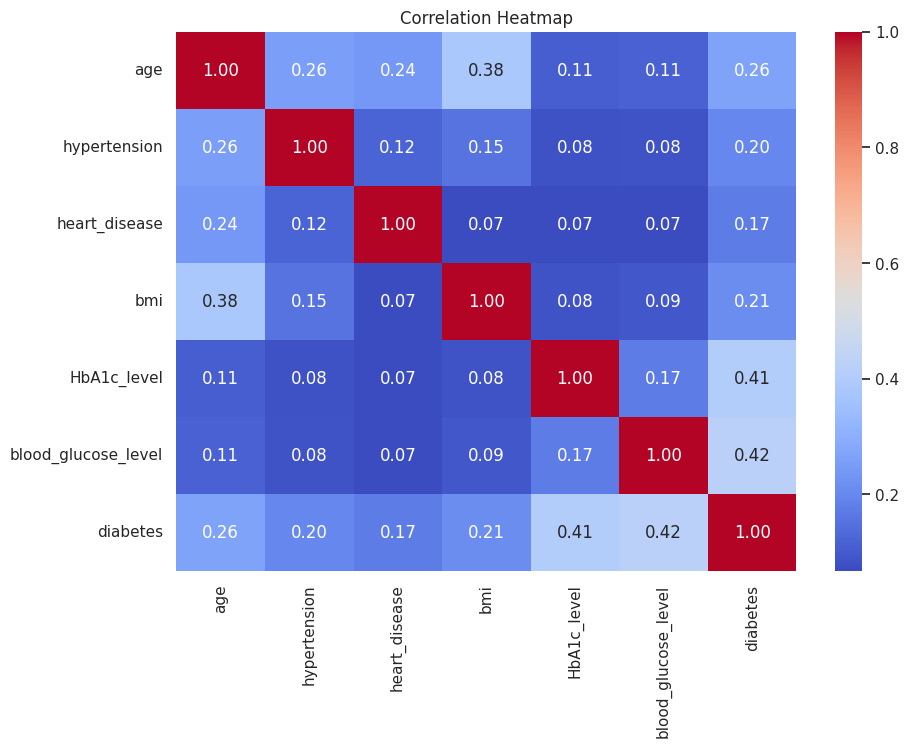

In [106]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

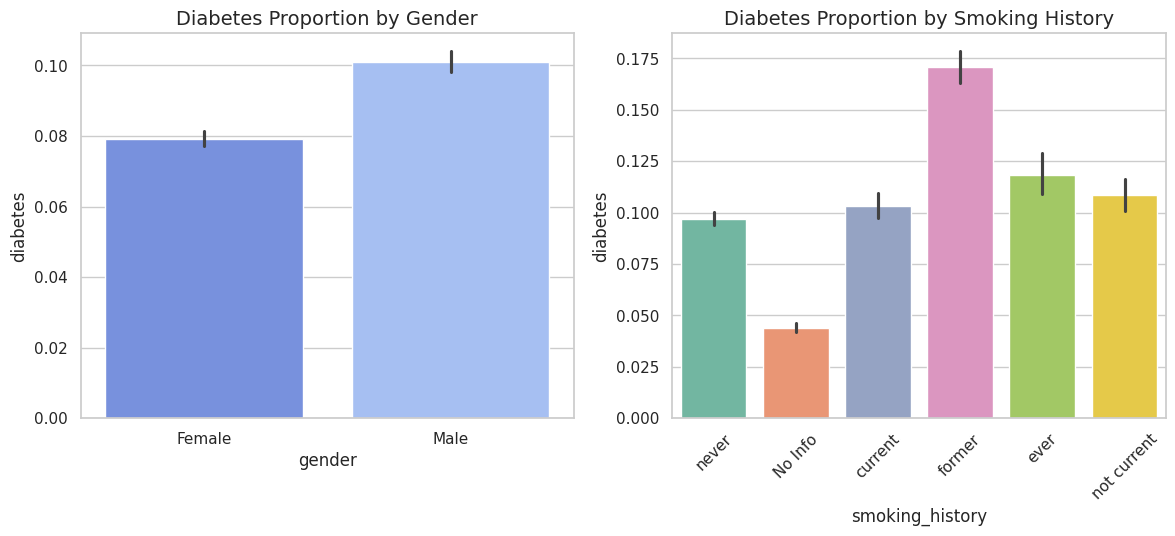

gender
Female    58.430928
Male      41.569072
Name: proportion, dtype: float64
smoking_history
never          35.776839
No Info        34.205271
former          9.671749
current         9.565661
not current     6.622220
ever            4.158259
Name: proportion, dtype: float64


In [107]:
# 1. Bar Charts (رسمتين بار شارت)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
palette_1 = sns.color_palette("coolwarm")
palette_2 = sns.color_palette("Set2")
sns.barplot(data=df, x='gender', y='diabetes', palette=palette_1)
plt.title('Diabetes Proportion by Gender', fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='smoking_history', y='diabetes', palette=palette_2)
plt.xticks(rotation=45)
plt.title('Diabetes Proportion by Smoking History', fontsize=14)
plt.show()

print(df["gender"].value_counts(normalize=True)*100)
print('='*50)
print(df["smoking_history"].value_counts(normalize=True)*100)

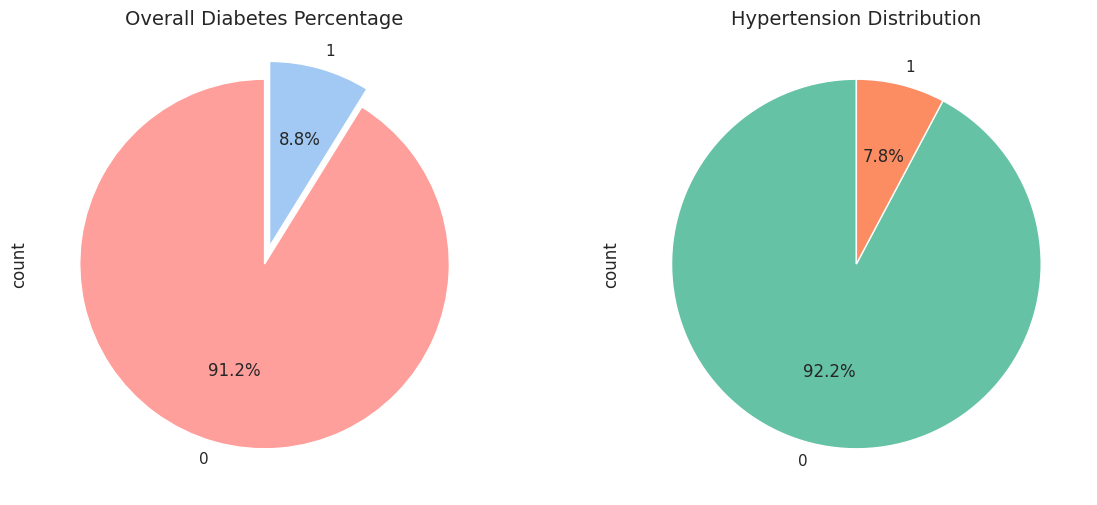

In [108]:
# 2. Pie Charts (رسمتين باي شارت)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
# Color palettes
palette_1 = sns.color_palette("coolwarm")
palette_2 = sns.color_palette("Set2")
colors = sns.color_palette("pastel")
df['diabetes'].value_counts().plot.pie(autopct='%1.1f%%', colors=[colors[3], colors[0]], startangle=90, explode=(0, 0.1))
plt.title('Overall Diabetes Percentage', fontsize=14)

plt.subplot(1, 2, 2)
pie_colors = sns.color_palette("Set2", 2)

df['hypertension'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90
)
plt.title('Hypertension Distribution', fontsize=14)
plt.show()

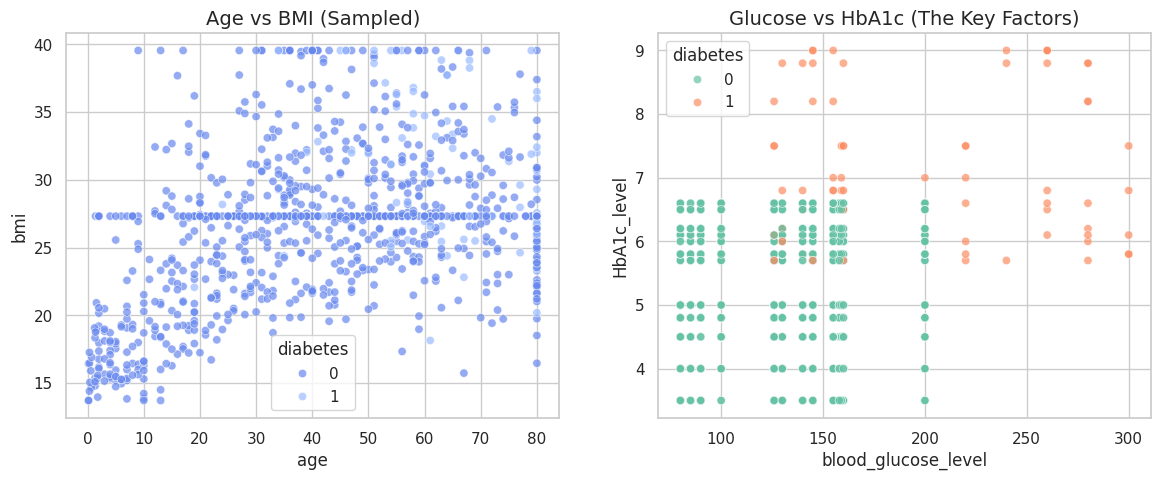

In [109]:
# 4. Scatter Plots (رسمتين سكاتر - للعلاقات القوية)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
# هناخد عينة عشان الرسمة متكنش تقيلة أوي
sns.scatterplot(data=df.sample(1000), x='age', y='bmi', hue='diabetes', palette=palette_1, alpha=0.7)
plt.title('Age vs BMI (Sampled)', fontsize=14)

plt.subplot(1, 2, 2)
sns.scatterplot(data=df.sample(1000), x='blood_glucose_level', y='HbA1c_level', hue='diabetes', palette=palette_2, alpha=0.7)
plt.title('Glucose vs HbA1c (The Key Factors)', fontsize=14)
plt.show()

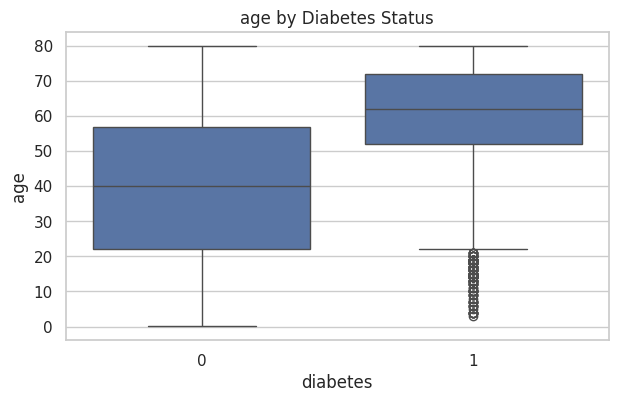

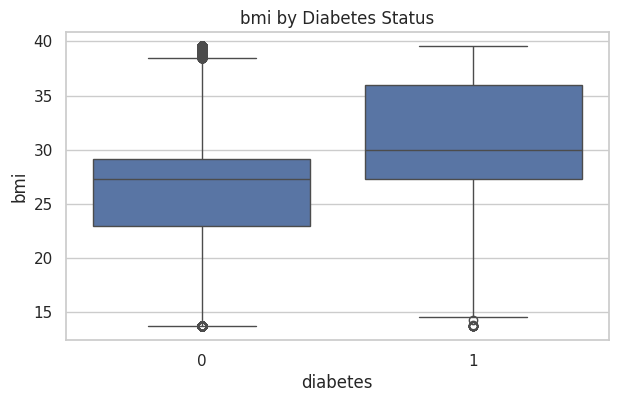

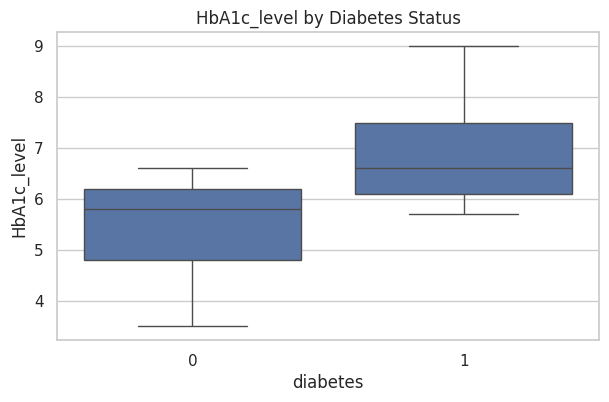

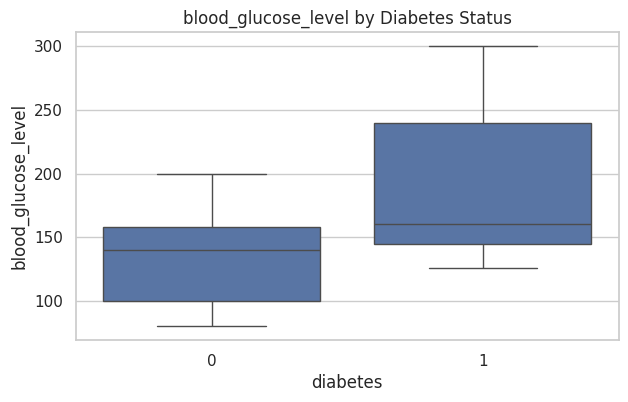

In [110]:
# Numerical features vs target
selected_numeric = [col for col in ["age", "bmi", "HbA1c_level", "blood_glucose_level"] if col in df.columns]

for col in selected_numeric:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="diabetes", y=col)
    plt.title(f"{col} by Diabetes Status")
    plt.show()

## 6. Feature Engineering

In a realistic diabetes **risk prediction** setting, using diagnostic indicators such as `HbA1c_level` and `blood_glucose_level`
can introduce target leakage, because they are strongly tied to the diagnosis itself.

To build a more realistic model, we will:
- create engineered features from indirect risk factors
- drop leakage-prone columns before training

In [111]:
# Create categorical engineered features
age_bins = [0, 12, 19, 39, 59, df["age"].max() + 1]
age_labels = ["0-12", "13-19", "20-39", "40-59", "60+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

bmi_bins = [0, 18.5, 25, 30, df["bmi"].max() + 1]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df["bmi_category"] = pd.cut(df["bmi"], bins=bmi_bins, labels=bmi_labels, right=False)

# Create numerical engineered features
df["cardio_risk"] = df["hypertension"] + df["heart_disease"]
df["age_bmi_interaction"] = df["age"] * df["bmi"]

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group,bmi_category,cardio_risk,age_bmi_interaction
0,Female,80.0,0,1,never,25.19,6.6,140,0,60+,Overweight,1,2015.20
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,40-59,Overweight,0,1475.28
2,Male,28.0,0,0,never,27.32,5.7,158,0,20-39,Overweight,0,764.96
3,Female,36.0,0,0,current,23.45,5.0,155,0,20-39,Normal,0,844.20
4,Male,76.0,1,1,current,20.14,4.8,155,0,60+,Normal,2,1530.64


In [112]:
# Drop leakage-prone columns if they exist
leakage_cols = [col for col in ["HbA1c_level", "blood_glucose_level"] if col in df.columns]
df_model = df.drop(columns=leakage_cols).copy()

print("Dropped leakage-prone columns:", leakage_cols)
print("Remaining columns:")
print(df_model.columns.tolist())

Dropped leakage-prone columns: ['HbA1c_level', 'blood_glucose_level']
Remaining columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'diabetes', 'age_group', 'bmi_category', 'cardio_risk', 'age_bmi_interaction']


## 7. Encoding and Train-Test Split

In [113]:
categorical_features = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (76916, 19)
Test shape: (19230, 19)


In [114]:
# Scale data for models that benefit from scaling
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaled_columns = X_train.select_dtypes(include=np.number).columns
X_train_scaled[scaled_columns] = scaler.fit_transform(X_train[scaled_columns])
X_test_scaled[scaled_columns] = scaler.transform(X_test[scaled_columns])

X_train_scaled.head()

,age,hypertension,heart_disease,bmi,cardio_risk,age_bmi_interaction,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_group_13-19,age_group_20-39,age_group_40-59,age_group_60+,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
79000,0.144164,-0.290873,-0.206441,-0.532977,-0.337475,-0.152537,True,False,False,False,False,False,False,False,True,False,True,False,False
32011,0.989825,-0.290873,-0.206441,1.013465,-0.337475,1.346109,False,False,False,True,False,False,False,False,False,True,False,False,True
95559,0.144164,-0.290873,-0.206441,0.049471,-0.337475,0.071229,False,False,False,False,False,False,False,False,True,False,False,True,False
32057,0.099655,3.437926,-0.206441,0.309463,2.501241,0.129516,True,False,False,False,False,False,False,False,True,False,False,True,False
97797,-0.656989,-0.290873,-0.206441,-0.092342,-0.337475,-0.670247,False,False,False,False,False,True,False,True,False,False,False,True,False


## 8. Model Training and Evaluation

In [115]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_proba)
    }
    return metrics

results = []

In [116]:
# Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="liblinear"
)

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log))

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     17534
           1       0.21      0.78      0.33      1696

    accuracy                           0.72     19230
   macro avg       0.59      0.75      0.58     19230
weighted avg       0.90      0.72      0.78     19230



In [117]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     17534
           1       0.23      0.26      0.24      1696

    accuracy                           0.86     19230
   macro avg       0.58      0.59      0.58     19230
weighted avg       0.87      0.86      0.86     19230



In [118]:
# XGBoost
if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb))

    print("XGBoost Results")
    print(classification_report(y_test, y_pred_xgb))
else:
    print("Skipping XGBoost because the package is not available.")

XGBoost Results
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     17534
           1       0.21      0.77      0.33      1696

    accuracy                           0.73     19230
   macro avg       0.59      0.75      0.58     19230
weighted avg       0.90      0.73      0.78     19230



## 9. Results Comparison

In [119]:
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.720021,0.209515,0.784198,0.330681,0.826506
1,XGBoost,0.725949,0.211774,0.774175,0.332573,0.821674
2,Random Forest,0.857774,0.229286,0.259434,0.243430,0.736937


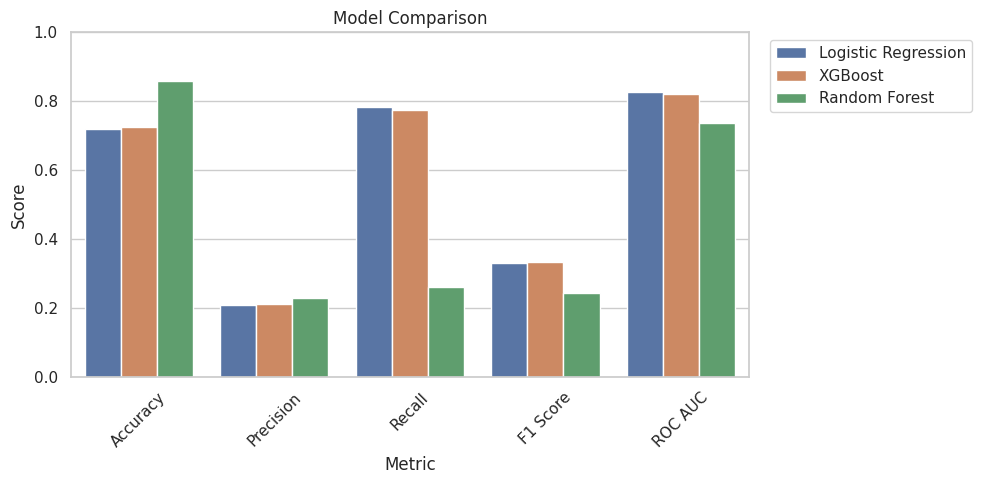

In [120]:
# Plot model comparison
if not results_df.empty:
    plt.figure(figsize=(10, 5))
    results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
    sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
    plt.title("Model Comparison")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

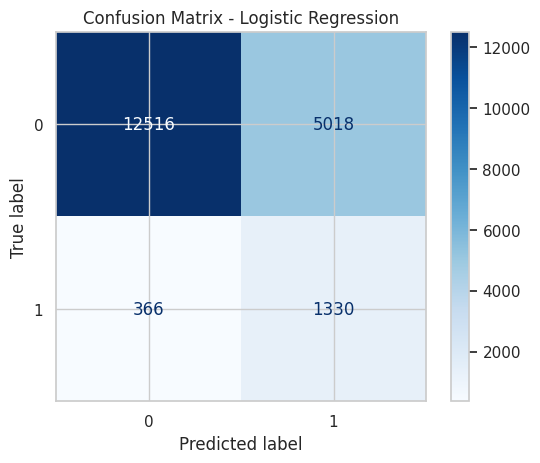

In [121]:
# Confusion matrix for the best available model
best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    cm = confusion_matrix(y_test, y_pred_log)
elif best_model_name == "Random Forest":
    cm = confusion_matrix(y_test, y_pred_rf)
elif best_model_name == "XGBoost":
    cm = confusion_matrix(y_test, y_pred_xgb)
else:
    cm = None

if cm is not None:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {best_model_name}")
    plt.show()

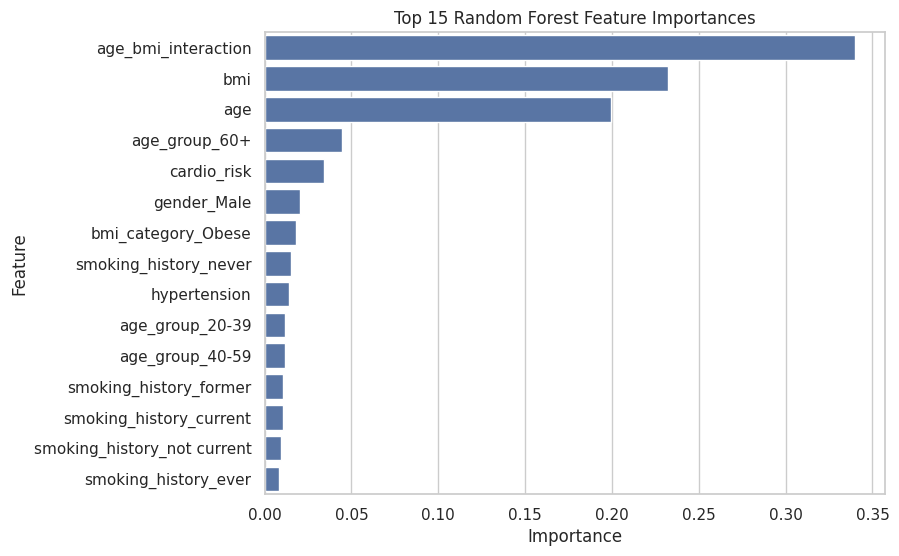

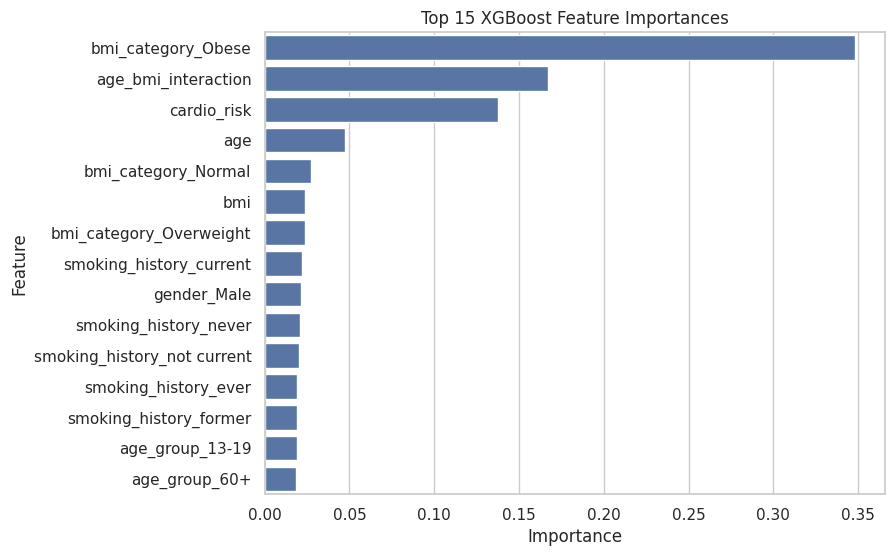

In [122]:
# Feature importance for tree-based models
if "rf_model" in globals():
    rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=rf_importance.values, y=rf_importance.index)
    plt.title("Top 15 Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

if XGBOOST_AVAILABLE and "xgb_model" in globals():
    xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
    plt.title("Top 15 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

## 10. Conclusion

### Key Takeaways
- The project followed a complete ML workflow from data loading to model evaluation.
- Duplicate rows were removed and the `gender` feature was cleaned.
- Additional features such as `age_group`, `bmi_category`, `cardio_risk`, and `age_bmi_interaction` were engineered.
- Leakage-prone columns were excluded to make the model more realistic for risk prediction.
- Multiple models were compared to identify the strongest performer.

### Suggested Next Steps
- Tune hyperparameters using GridSearchCV or RandomizedSearchCV
- Save the best model with `joblib` or `pickle`
- Build a small deployment demo using Streamlit
- Add ROC curve and precision-recall curve visualizations